In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("travel_data.csv")

df.head()

,user_id,search_count,booking_history,price_sensitivity,booked
0,1,12,4,0.3,1
1,2,3,0,0.8,0
2,3,15,5,0.4,1
3,4,8,2,0.6,1
4,5,1,0,0.9,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            30 non-null     int64  
 1   search_count       30 non-null     int64  
 2   booking_history    30 non-null     int64  
 3   price_sensitivity  30 non-null     float64
 4   booked             30 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 1.3 KB


In [26]:
df.describe()

,user_id,search_count,booking_history,price_sensitivity,booked
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,9.200000,2.666667,0.556667,0.533333
std,8.803408,5.677542,2.523453,0.235889,0.507416
min,1.000000,1.000000,0.000000,0.200000,0.000000
25%,8.250000,4.250000,0.250000,0.325000,0.000000
50%,15.500000,8.500000,2.000000,0.600000,1.000000
75%,22.750000,13.750000,4.750000,0.775000,1.000000
max,30.000000,20.000000,8.000000,0.900000,1.000000


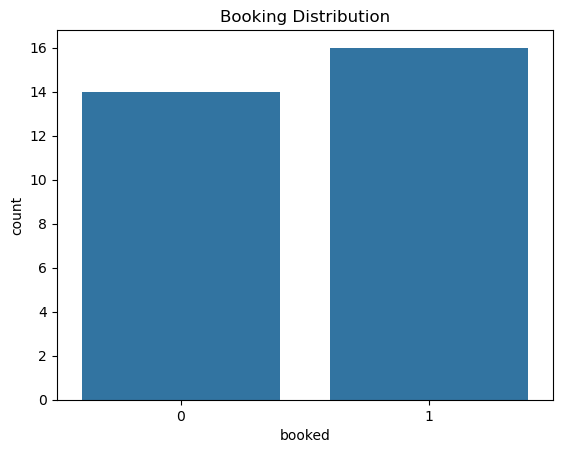

In [27]:
sns.countplot(x="booked", data=df)
plt.title("Booking Distribution")
plt.show()

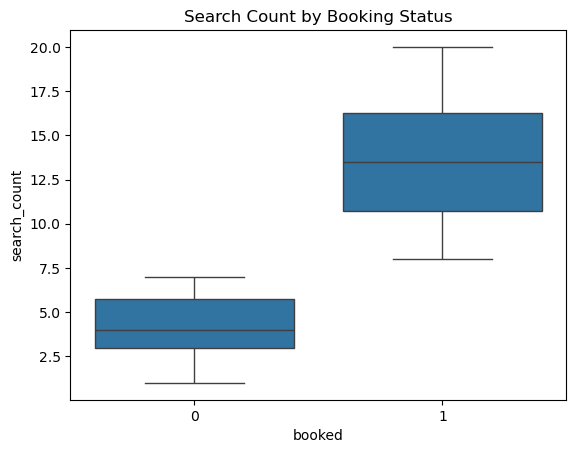

In [28]:
sns.boxplot(x="booked", y="search_count", data=df)
plt.title("Search Count by Booking Status")
plt.show()

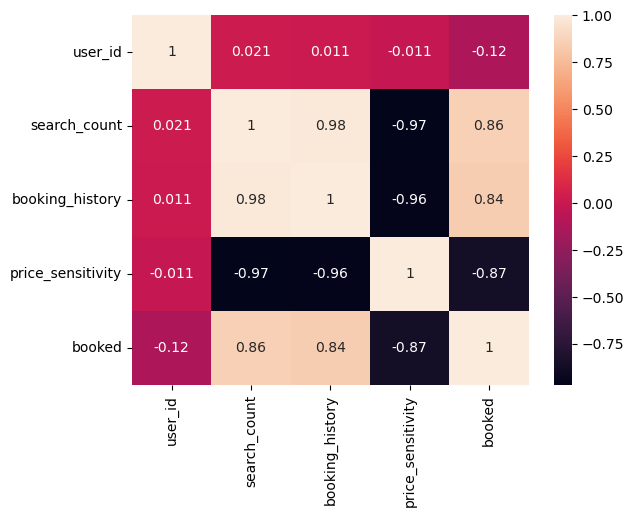

In [29]:
corr = df.corr()

sns.heatmap(corr, annot=True)
plt.show()

In [32]:
insert_query = """
INSERT INTO travel_data VALUES
(1,10,3,0.8,1),
(2,2,0,0.3,0),
(3,15,5,0.6,1),
(4,1,0,0.9,0),
(5,7,2,0.4,1);
"""

cursor = conn.cursor()
cursor.execute(insert_query)
conn.commit()

In [33]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="db",
    database="travel_db",
    user="tiket",
    password="tiket123"
)

query = "SELECT * FROM travel_data"

df = pd.read_sql(query, conn)

df.head()

/tmp/ipykernel_764/2833834171.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,user_id,search_count,booking_history,price_sensitivity,booked
0,1,10,3,0.8,1
1,2,2,0,0.3,0
2,3,15,5,0.6,1
3,4,1,0,0.9,0
4,5,7,2,0.4,1


In [34]:
df.describe()

,user_id,search_count,booking_history,price_sensitivity,booked
count,5.000000,5.000000,5.00000,5.000000,5.000000
mean,3.000000,7.000000,2.00000,0.600000,0.600000
std,1.581139,5.787918,2.12132,0.254951,0.547723
min,1.000000,1.000000,0.00000,0.300000,0.000000
25%,2.000000,2.000000,0.00000,0.400000,0.000000
50%,3.000000,7.000000,2.00000,0.600000,1.000000
75%,4.000000,10.000000,3.00000,0.800000,1.000000
max,5.000000,15.000000,5.00000,0.900000,1.000000


<Axes: xlabel='booked', ylabel='count'>

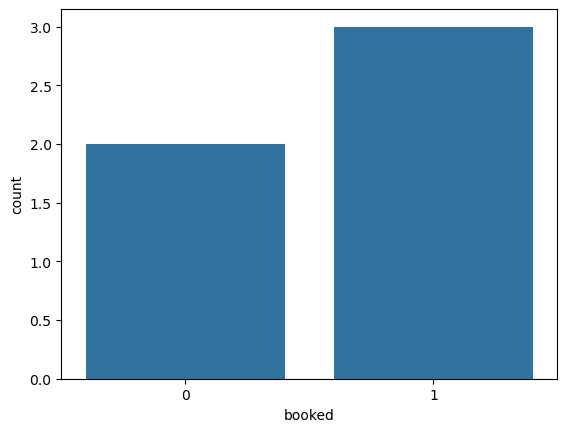

In [35]:
import seaborn as sns
sns.countplot(x="booked", data=df)

In [41]:
import os
os.listdir()

['.ipynb_checkpoints', 'eda.ipynb', 'init.sql', 'travel_data.csv']

In [43]:
import os

os.makedirs("data", exist_ok=True)

In [42]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "user_id": np.arange(1, n+1),
    "search_count": np.random.randint(1, 30, n),
    "booking_history": np.random.randint(0, 10, n),
    "price_sensitivity": np.round(np.random.uniform(0.1, 1.0, n), 2)
}

df = pd.DataFrame(data)

# aturan sederhana probabilitas booking
prob_booking = (
    0.3 * (df["search_count"]/30) +
    0.4 * (df["booking_history"]/10) +
    0.3 * (1 - df["price_sensitivity"])
)

df["booked"] = (prob_booking > 0.5).astype(int)

df.head()

,user_id,search_count,booking_history,price_sensitivity,booked
0,1,7,2,0.75,0
1,2,20,6,0.54,1
2,3,29,5,0.89,1
3,4,15,1,0.91,0
4,5,11,5,0.48,0


In [44]:
df.to_csv("data/travel_data_large.csv", index=False)

In [45]:
os.listdir("data")

['travel_data_large.csv']

In [46]:
import psycopg2

conn = psycopg2.connect(
    host="db",
    database="travel_db",
    user="tiket",
    password="tiket123"
)

cursor = conn.cursor()

for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO travel_data
        (user_id, search_count, booking_history, price_sensitivity, booked)
        VALUES (%s,%s,%s,%s,%s)
    """, tuple(row))

conn.commit()

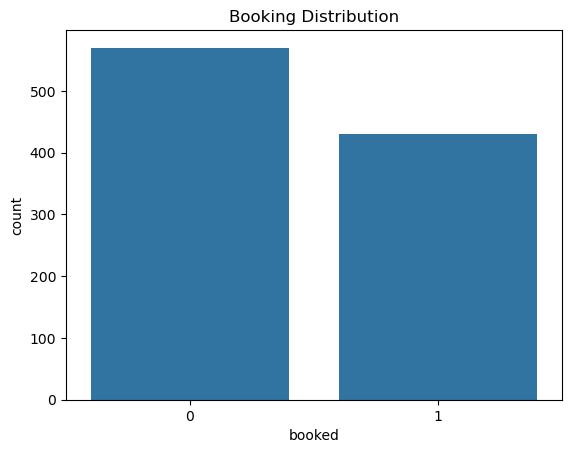

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="booked", data=df)
plt.title("Booking Distribution")
plt.show()

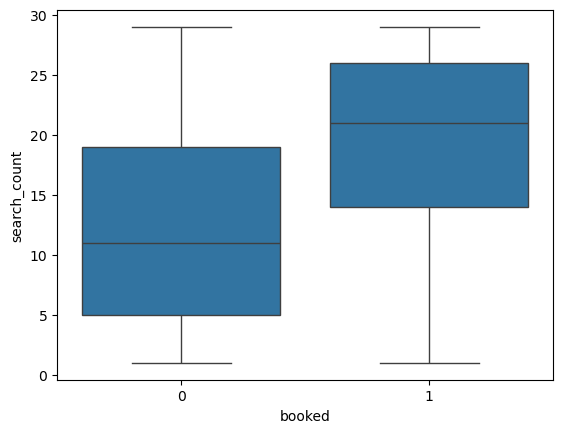

In [48]:
sns.boxplot(x="booked", y="search_count", data=df)
plt.show()